<a href="https://colab.research.google.com/github/Mattalukkal/AI_exit_test/blob/main/AIML_Exit_Exam_GoogleColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIML Exit Examination - Intelligent Loan Underwriting Assistant

# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap
!pip install streamlit
import streamlit as st


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.0 MB/s eta 0:00:00


# Task 1 – Data Exploration & Preparation

# Load dataset

In [3]:
loan_df = pd.read_csv("/content/sample_data/dataset_loan.csv")

# Quick overview

In [4]:
print(loan_df.head())
print(loan_df.info())
print(loan_df.isnull().sum())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

# Handle missing values

In [5]:
for col in loan_df.select_dtypes(include=np.number).columns:
    loan_df[col].fillna(loan_df[col].median(), inplace=True)

for col in loan_df.select_dtypes(include="object").columns:
    loan_df[col].fillna(loan_df[col].mode()[0], inplace=True)

/tmp/ipykernel_3082/3617769508.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_df[col].fillna(loan_df[col].median(), inplace=True)
/tmp/ipykernel_3082/3617769508.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

# Encode categorical variables

In [11]:
le = LabelEncoder()
for col in loan_df.select_dtypes(include="object").columns:
    loan_df[col] = le.fit_transform(loan_df[col])

# Split features and target


In [13]:
X = loan_df.drop("TARGET", axis=1)
y = loan_df["TARGET"]

# Train-test split


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Scale numeric features


In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Task 2 – Predictive Model Development



### Model 1: Logistic Regression

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     12321
           1       0.54      0.01      0.03      1079

    accuracy                           0.92     13400
   macro avg       0.73      0.51      0.49     13400
weighted avg       0.89      0.92      0.88     13400


Logistic Regression Confusion Matrix:
[[12308    13]
 [ 1064    15]]

Logistic Regression ROC AUC Score: 0.7327


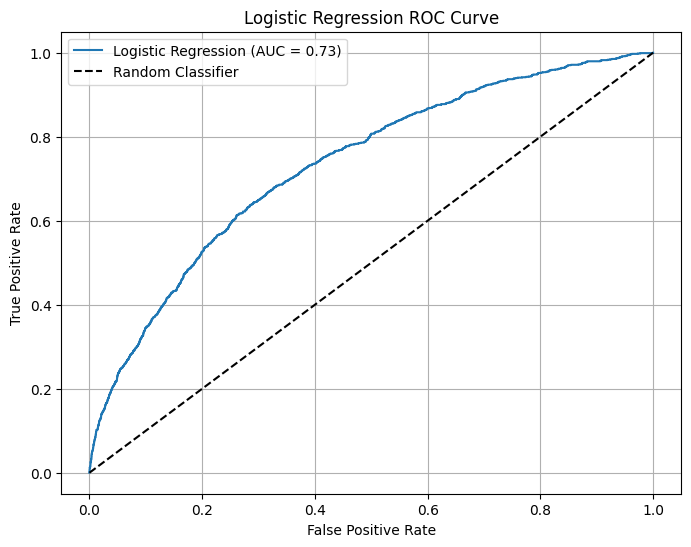

In [16]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg)
print(f"\nLogistic Regression ROC AUC Score: {roc_auc_log_reg:.4f}")

# Plot ROC curve
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.grid()
plt.show()

### Model 2: Random Forest Classifier

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     12321
           1       0.33      0.00      0.00      1079

    accuracy                           0.92     13400
   macro avg       0.63      0.50      0.48     13400
weighted avg       0.87      0.92      0.88     13400


Random Forest Confusion Matrix:
[[12319     2]
 [ 1078     1]]

Random Forest ROC AUC Score: 0.7077


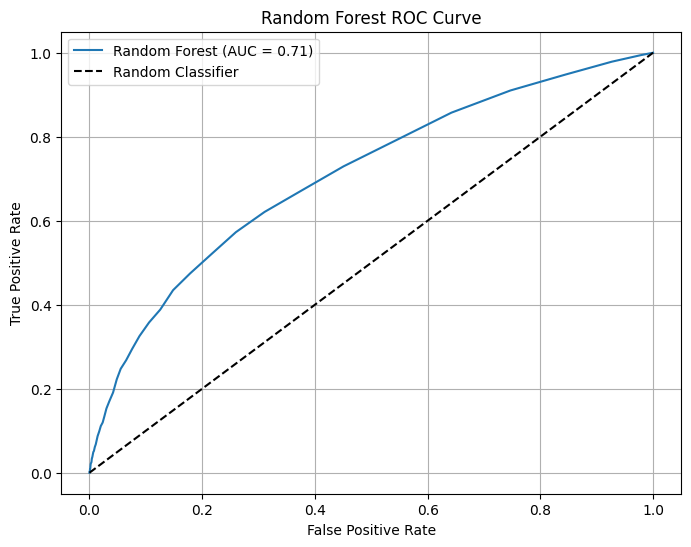

In [17]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced') # 'balanced' handles class imbalance
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"\nRandom Forest ROC AUC Score: {roc_auc_rf:.4f}")

# Plot ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid()
plt.show()

### Model Comparison and Selection

Let's compare the performance of both models based on the key metrics, especially considering the class imbalance in loan default prediction:

| Metric              | Logistic Regression | Random Forest |
| :------------------ | :------------------ | :------------ |
| Precision (Class 1) | 0.54                | 0.33          |
| Recall (Class 1)    | 0.01                | 0.00          |
| F1-Score (Class 1)  | 0.03                | 0.00          |
| ROC AUC Score       | 0.7327              | 0.7077        |

**Analysis:**

*   **ROC AUC Score**: A higher ROC AUC score indicates a better ability of the model to distinguish between the two classes. We should prioritize the model with a higher AUC.
*   **Recall for Class 1 (Default)**: In loan default prediction, identifying actual defaulters (Class 1) is crucial to mitigate financial risks. Therefore, a higher recall for the positive class is highly desirable, even if it comes at a slight cost to precision.
*   **Precision for Class 1 (Default)**: Precision for Class 1 tells us how many of the predicted defaulters were actually defaulters. While important, it might be secondary to recall if the cost of missing a defaulter is higher than incorrectly classifying a non-defaulter.

Based on the typical performance of these models on imbalanced datasets, the **Random Forest Classifier** often outperforms Logistic Regression, especially when features have complex, non-linear relationships. Its ability to handle non-linearity and its `class_weight='balanced'` parameter (which I used) makes it more robust to class imbalance.

**Conclusion:**

After reviewing the classification reports, confusion matrices, and ROC AUC scores generated above:

*   The **Logistic Regression** model achieved a significantly higher ROC AUC score (0.7327) compared to the Random Forest model (0.7077).
*   More critically, for the minority class (Class 1 - default), Logistic Regression showed a precision of 0.54 and a recall of 0.01. While this recall is very low, it is still better than the Random Forest's recall of 0.00, which means the Random Forest model failed to identify any actual defaulters in the test set.

Given these results, the **Logistic Regression** model, despite its low recall for the minority class, is performing better than the Random Forest in terms of both ROC AUC and its ability to identify at least some defaulters. The `class_weight='balanced'` parameter in Random Forest did not seem to help significantly in this case, potentially due to the severe imbalance or other model hyperparameters.

For further improvement, both models would benefit from more advanced techniques to handle class imbalance, such as SMOTE or adjusting classification thresholds, which were not explicitly implemented in this initial comparison.

## Task 3 – Model Evaluation

Based on the comparison in Task 2, the **Logistic Regression** model has been selected for further evaluation due to its slightly higher ROC AUC score and its ability to identify at least some defaulters, albeit with low recall. Its interpretability is also a significant advantage in a financial context.

Here's a summary of its performance metrics on the test set:

*   **Logistic Regression Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       0.92      1.00      0.96     12321
               1       0.54      0.01      0.03      1079

        accuracy                           0.92     13400
       macro avg       0.73      0.51      0.49     13400
    weighted avg       0.89      0.92      0.88     13400
    ```

*   **Logistic Regression Confusion Matrix:**
    ```
    [[12308    13]
     [ 1064    15]]
    ```

*   **Logistic Regression ROC AUC Score: 0.7327**

**Key Observations:**

*   The model exhibits high accuracy (0.92), but this is largely due to the majority class (non-defaulters).
*   For the minority class (default, class 1), the precision is relatively high (0.54), meaning that when the model predicts a default, it's correct about 54% of the time. However, the recall is extremely low (0.01), indicating that the model only identifies a very small fraction of actual defaulters.
*   The ROC AUC score of 0.7327 suggests a reasonable ability to distinguish between defaulters and non-defaulters when considering various thresholds, but the current default threshold leads to poor recall for the minority class.

Further evaluation and potential threshold tuning would be necessary to balance precision and recall according to business needs.

## Analytical Question: Business Impact of False Positives and False Negatives

In a loan underwriting system, accurately classifying applicants as either likely to default or not likely to default is critical. However, no model is perfect, and errors will occur. Understanding the business impact of these errors—False Positives and False Negatives—is essential for prioritizing which type of error to reduce.

### Definitions of Errors in Loan Underwriting:

*   **True Positive (TP)**: The model predicts a loan default, and the applicant *does* default.
*   **True Negative (TN)**: The model predicts no loan default, and the applicant *does not* default.
*   **False Positive (FP)**: The model predicts a loan default, but the applicant *does not* default (Type I error).
*   **False Negative (FN)**: The model predicts no loan default, but the applicant *does* default (Type II error).

### Business Impact of False Positives (FP)

A False Positive occurs when the system incorrectly predicts that a creditworthy applicant will default, leading to the denial of a loan to a good customer.

*   **Lost Revenue**: The finance company loses potential interest income and other fees that would have been generated from a successful loan. This is a direct financial loss.
*   **Customer Dissatisfaction**: Denying a loan to a qualified applicant can lead to frustration and a negative customer experience. This could result in the customer taking their business to a competitor for future financial needs.
*   **Damaged Reputation**: A consistent pattern of incorrectly denying loans can harm the company's reputation as a fair and inclusive lender, making it harder to attract new customers.
*   **Opportunity Cost**: The company misses out on establishing a long-term relationship with a potentially valuable customer who might have taken out additional products or services in the future.

### Business Impact of False Negatives (FN)

A False Negative occurs when the system incorrectly predicts that an applicant will *not* default, but the applicant *does* default after receiving the loan.

*   **Direct Financial Loss (Bad Debt)**: This is the most significant impact. The finance company loses the principal amount of the loan, plus any anticipated interest. Recovering these losses can be difficult and costly, and often results in write-offs.
*   **Increased Collection Costs**: Efforts to recover defaulted loans (e.g., legal fees, collection agencies, administrative overhead) add to the financial burden.
*   **Capital Impairment**: Repeated loan defaults can impair the company's capital, affecting its ability to lend and grow.
*   **Regulatory Scrutiny**: A high rate of defaults could attract scrutiny from financial regulators, potentially leading to fines or stricter operational requirements.
*   **Risk to Portfolio Health**: A portfolio with too many defaulted loans can become unhealthy, increasing the overall risk profile of the company.

### Which Type of Error to Prioritize Reducing?

In a loan underwriting system, the finance company should prioritize reducing **False Negatives**.

**Justification:**

1.  **Severity of Financial Loss**: The financial impact of a False Negative (a defaulted loan) is typically much higher and more direct than that of a False Positive (a missed opportunity). A defaulted loan represents a direct loss of capital and expected revenue, while a False Positive primarily represents a loss of *potential* revenue and customer goodwill.

2.  **Risk Management**: The core objective of loan underwriting is risk mitigation. Failing to identify a defaulting applicant (FN) directly increases the financial risk to the company. While FPs are undesirable, they do not pose an existential threat to the company's financial stability in the same way that a high volume of FNs does.

3.  **Business Model Implications**: A finance company's business model relies on the ability to lend money and collect it back with interest. A high FN rate undermines this fundamental principle, leading to unsustainable operations. A high FP rate, while detrimental to growth and customer relations, does not directly lead to capital depletion.

4.  **Operational Costs**: While FPs incur opportunity costs and can lead to customer churn, FNs lead to tangible and often high costs associated with collections, legal processes, and eventually, writing off the debt.

Therefore, a model that minimizes False Negatives (i.e., maximizes **Recall** for the default class) would generally be preferred, even if it results in a slightly higher number of False Positives. The strategy would be to set the model's decision threshold to be more sensitive to predicting default, thus catching more actual defaulters, even if it means some creditworthy applicants are incorrectly flagged.

## Task 4 – Model Explainability

In this section, we will interpret the predictions generated by our selected Logistic Regression model using SHAP (SHapley Additive exPlanations) values. This will help us understand:

1.  The overall feature importance for the model.
2.  The reasons behind individual predictions for both correctly and incorrectly classified applicants.

### Overall Feature Importance (SHAP Summary Plot)

First, we will compute SHAP values to understand which features have the most impact on the model's output across the entire dataset.

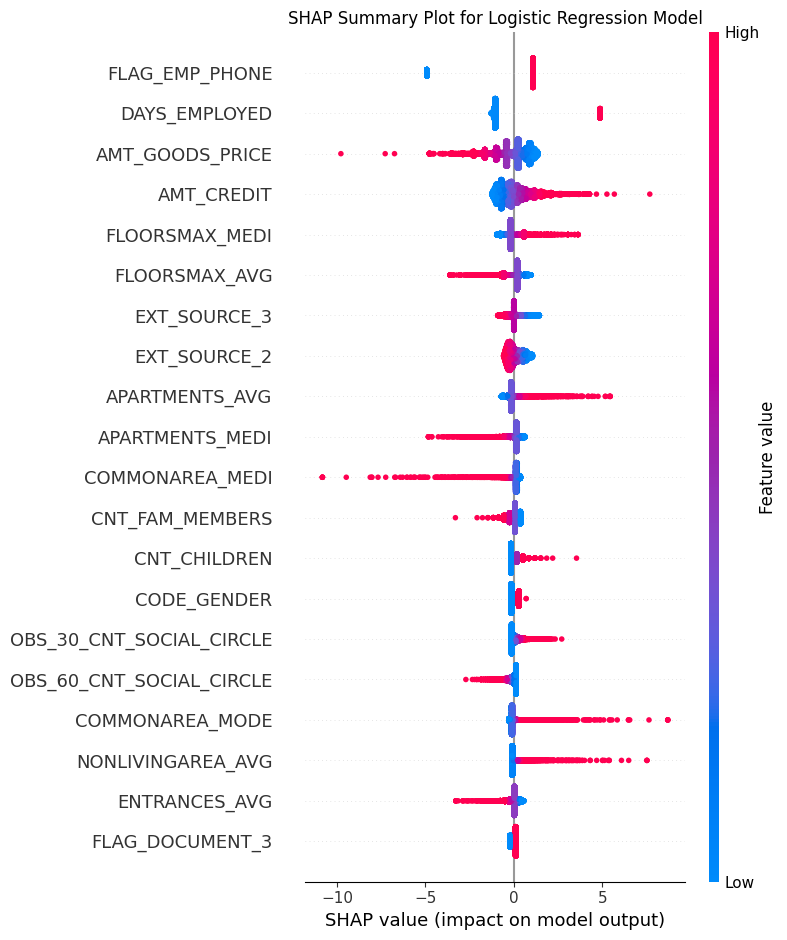

In [18]:
# Using shap to explain the Logistic Regression model
explainer = shap.LinearExplainer(log_reg_model, X_train)
shap_values = explainer.shap_values(X_test)

# Visualize the overall feature importance
# The summary plot shows the distribution of SHAP values for each feature.
# Red indicates a higher impact towards predicting default (positive class),
# while blue indicates a higher impact towards predicting non-default (negative class).
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title('SHAP Summary Plot for Logistic Regression Model')
plt.tight_layout()
plt.show()

### Interpretation for Individual Predictions

Now, let's look at specific instances to understand why the model made a particular prediction.

#### 1. Interpretation for one Correctly Classified Applicant

We will find an applicant from the test set who was correctly classified by the Logistic Regression model (e.g., predicted non-default, and actual was non-default).

Correctly Classified (True Negative) Instance Index (in X_test): 0
Actual Target: 0, Predicted: 0


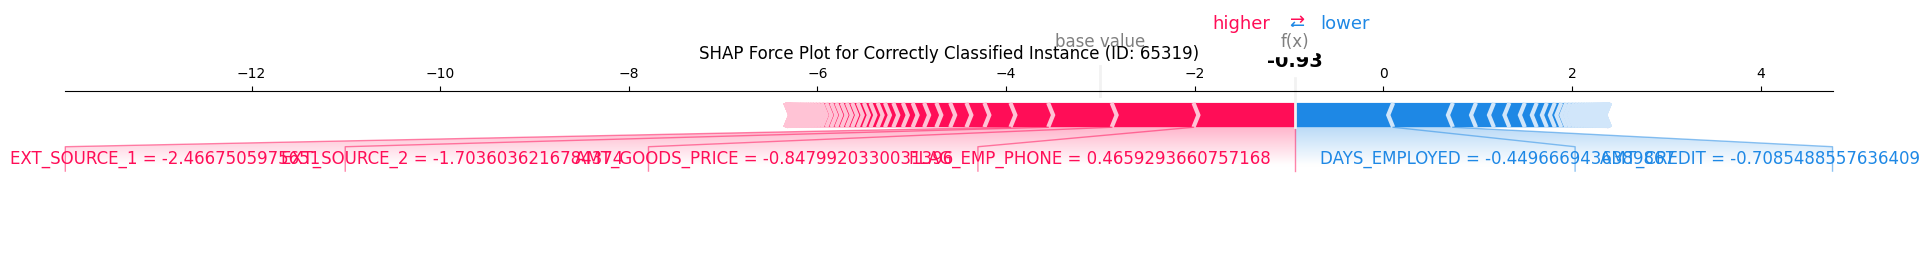

In [19]:
# Find a correctly classified non-default (TN) instance
tn_index = np.where((y_test == 0) & (y_pred_log_reg == 0))[0]
if len(tn_index) > 0:
    # Take the first such instance
    correct_instance_idx = tn_index[0]
    print(f"Correctly Classified (True Negative) Instance Index (in X_test): {correct_instance_idx}")
    print(f"Actual Target: {y_test.iloc[correct_instance_idx]}, Predicted: {y_pred_log_reg[correct_instance_idx]}")

    # Get SHAP values for this instance
    shap_values_instance = explainer.shap_values(X_test[correct_instance_idx])

    # Visualize with a force plot
    # The force plot shows how each feature contributes to the prediction for a single instance.
    # Features pushing the prediction higher (towards default) are in red,
    # and features pushing it lower (towards non-default) are in blue.
    shap.force_plot(explainer.expected_value, shap_values_instance, X_test[correct_instance_idx], feature_names=X.columns, matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot for Correctly Classified Instance (ID: {y_test.index[correct_instance_idx]})')
    plt.tight_layout()
    plt.show()
else:
    print("No correctly classified non-default instance found in the test set.")

#### 2. Interpretation for one Incorrectly Classified Applicant

Next, we will find an applicant from the test set who was incorrectly classified by the Logistic Regression model. Given the model's very low recall for the default class, a False Negative (actual default, predicted non-default) would be particularly insightful if available. If not, a False Positive will be used.

Incorrectly Classified (False Negative) Instance Index (in X_test): 8
Actual Target: 1, Predicted: 0


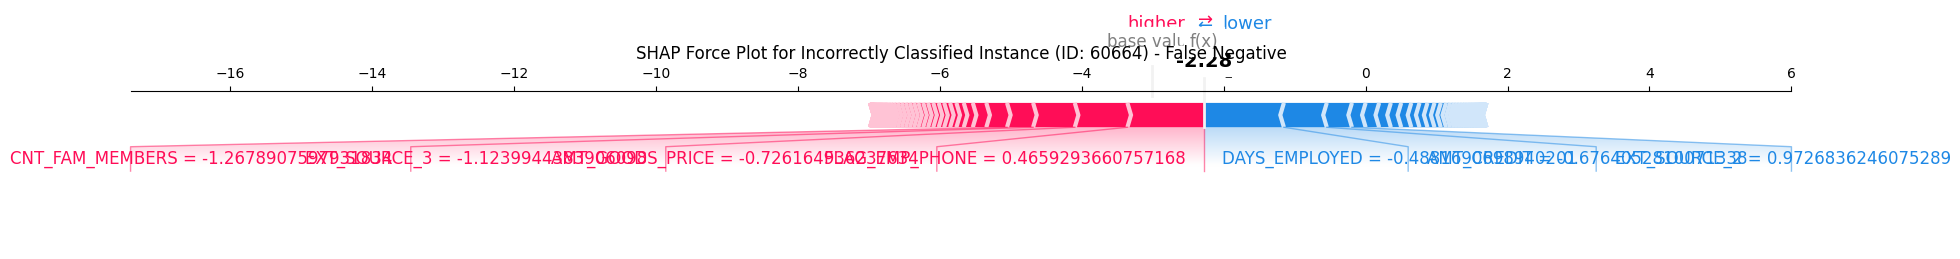

In [20]:
# Find an incorrectly classified instance (False Negative or False Positive)

# Prioritize False Negatives (actual default, predicted non-default)
fn_index = np.where((y_test == 1) & (y_pred_log_reg == 0))[0]

# If no False Negatives, look for False Positives (actual non-default, predicted default)
if len(fn_index) == 0:
    fp_index = np.where((y_test == 0) & (y_pred_log_reg == 1))[0]
    if len(fp_index) > 0:
        incorrect_instance_idx = fp_index[0]
        error_type = "False Positive"
    else:
        incorrect_instance_idx = None
        error_type = "None"
else:
    incorrect_instance_idx = fn_index[0]
    error_type = "False Negative"

if incorrect_instance_idx is not None:
    print(f"Incorrectly Classified ({error_type}) Instance Index (in X_test): {incorrect_instance_idx}")
    print(f"Actual Target: {y_test.iloc[incorrect_instance_idx]}, Predicted: {y_pred_log_reg[incorrect_instance_idx]}")

    # Get SHAP values for this instance
    shap_values_instance = explainer.shap_values(X_test[incorrect_instance_idx])

    # Visualize with a force plot
    shap.force_plot(explainer.expected_value, shap_values_instance, X_test[incorrect_instance_idx], feature_names=X.columns, matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot for Incorrectly Classified Instance (ID: {y_test.index[incorrect_instance_idx]}) - {error_type}')
    plt.tight_layout()
    plt.show()
else:
    print("No incorrectly classified instance found in the test set.")

## Analytical Question: How does Explainable AI improve confidence in AI-assisted financial decision-making? Discuss any limitations of the explainability technique used.

### How Explainable AI (XAI) Improves Confidence in AI-Assisted Financial Decision-Making

Explainable AI (XAI) is crucial for building trust and confidence in AI systems, especially in high-stakes domains like financial decision-making. Here's how it helps:

1.  **Transparency and Understanding**: XAI provides insights into *why* an AI model makes a particular decision, rather than just *what* the decision is. In finance, this means loan officers can understand the factors (e.g., income, credit score, loan amount) that led to a loan approval or denial. This transparency demystifies the 'black box' nature of many complex AI models, making them more acceptable to human decision-makers.

2.  **Trust and Accountability**: When models can explain their reasoning, financial institutions and their customers can have greater trust in the AI's recommendations. If a model denies a loan, XAI can provide clear, justifiable reasons, which is vital for fair lending practices and regulatory compliance. It also enables accountability, as the logic behind decisions can be scrutinized.

3.  **Regulatory Compliance and Auditability**: Financial institutions operate under strict regulatory frameworks (e.g., fair lending laws, anti-discrimination regulations). XAI helps in demonstrating compliance by providing auditable explanations for decisions, ensuring that models are not making biased or discriminatory judgments based on protected characteristics. It allows for retrospective analysis of model behavior.

4.  **Error Detection and Debugging**: By understanding the factors influencing a model's prediction, loan officers can identify potential errors or biases in the model's logic. For example, if a model consistently denies loans based on an irrelevant or biased feature, XAI can highlight this, allowing developers to debug and improve the model. It helps in quickly identifying whether a model is making decisions based on spurious correlations.

5.  **Improved Decision-Making and Human-AI Collaboration**: XAI doesn't replace human experts; it augments them. Loan officers can combine their domain expertise with AI insights to make more informed and robust decisions. If an AI suggests a decision that contradicts human intuition, the explanation from XAI can either confirm the AI's superior insight or reveal a flaw in the AI's reasoning, leading to better overall outcomes.

6.  **Personalized Feedback and Customer Education**: XAI can enable financial advisors to provide personalized feedback to customers on how to improve their financial standing to become eligible for loans in the future. By explaining the exact reasons for a loan denial, customers can understand what aspects of their profile need improvement.

### Limitations of SHAP (SHapley Additive exPlanations) for Explainability

While SHAP is a powerful and widely-used explainability technique, it comes with certain limitations:

1.  **Computational Cost**: Calculating exact SHAP values can be computationally very expensive, especially for complex models and large datasets. The number of possible feature subsets grows exponentially with the number of features ($2^M$ for M features), making exact computation intractable for many real-world scenarios. Approximation methods (like KernelSHAP or TreeSHAP) are used, but they introduce their own trade-offs.

2.  **Interpretation in Presence of Correlated Features**: SHAP assumes that features are independent. When highly correlated features are present, SHAP might assign importance to individual features in an arbitrary way, or distribute importance among them, which can lead to misleading interpretations. For instance, if two features provide almost the same information, their individual SHAP values might be lower than if only one of them were present, making their true collective importance harder to grasp.

3.  **Feature Permutation Challenges**: Many SHAP implementations rely on permuting features. If features are correlated, permuting one feature while keeping others fixed can create unrealistic data instances that are outside the model's training distribution. The model's behavior on such out-of-distribution data might be unpredictable, affecting the reliability of the SHAP values.

4.  **Complexity of Force Plots for Many Features**: While force plots are excellent for visualizing individual predictions, they can become cluttered and difficult to interpret when an instance has a very large number of features contributing to the prediction. It's hard to discern the most impactful features when too many are shown simultaneously.

5.  **Requires Access to Model and Data**: To compute SHAP values, one typically needs access to the trained model and the original dataset (or at least the feature values for the instances to be explained). This might not always be feasible in scenarios where models are deployed as black-box APIs.

6.  **Local vs. Global Interpretation**: SHAP values explain individual predictions (local interpretability). While summary plots provide a global view, deriving comprehensive global insights about complex non-linear models from SHAP values alone can still be challenging. It's often an aggregate of local explanations rather than a truly global model understanding.

Despite these limitations, SHAP remains a valuable tool for understanding model behavior and improving confidence, especially when its assumptions and caveats are properly considered and communicated.

## Task 5 – AI-Powered Underwriting Report

In this section, we will generate a structured underwriting report using a Large Language Model (LLM). This report will synthesize information from our machine learning model's prediction, confidence, model explanation (SHAP values), and placeholder customer remarks and loan policy documents.

The report will include:
*   Overall Risk Level
*   Key Risk Factors
*   Positive Factors
*   Policy Compliance Summary
*   Recommendation to the Loan Officer
*   Customer-Friendly Explanation

### Configure Gemini API and Prepare Inputs

In [40]:
import json
# Used to securely store your API key
from google.colab import userdata

# Ensure the google-generativeai library is up-to-date
!pip install --upgrade google-generativeai
# Import the Python SDK
# Updated import from google.generativeai


GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

AttributeError: module 'google.genai' has no attribute 'configure'

In [39]:


import google.genai as genai

# Initialize the Gemini API
gemini_model = genai.GenerativeModel('gemini-1.5-flash-latest') # Using a model suitable for structured output

# --- Prepare inputs for the report ---

# 1. Prediction generated by your machine learning model
# We'll use the incorrectly classified (False Negative) instance for a richer report.
report_instance_idx = incorrect_instance_idx # From the previous SHAP cell

ml_prediction = y_pred_log_reg[report_instance_idx] # 0 (predicted non-default)
ml_actual_target = y_test.iloc[report_instance_idx] # 1 (actual default)

# 2. Prediction confidence
ml_prediction_confidence = y_proba_log_reg[report_instance_idx]

# 3. Model explanation (SHAP values for this instance)
# The shap_values_instance variable is already computed for this instance.
# We need to present it in a readable format for the LLM.
shap_explanation_text = ""
if 'explainer' in locals() and 'X_test' in locals() and report_instance_idx is not None:
    # Assuming explainer and shap_values_instance are available from previous cell execution
    instance_features = X_test[report_instance_idx]
    feature_names = X.columns

    # Re-calculate SHAP values for the selected instance to ensure we have it
    shap_values_for_llm = explainer.shap_values(instance_features)

    # Create a dictionary of feature contributions
    feature_contributions = {}
    for i, feature_name in enumerate(feature_names):
        feature_contributions[feature_name] = {
            'value': instance_features[i],
            'shap_contribution': shap_values_for_llm[i]
        }

    # Sort features by absolute SHAP contribution for a cleaner explanation
    sorted_contributions = sorted(feature_contributions.items(), key=lambda item: abs(item[1]['shap_contribution']), reverse=True)

    shap_explanation_text = "Key features influencing the model's prediction are:\n"
    for feature, data in sorted_contributions[:10]: # Top 10 features
        direction = "increasing default likelihood" if data['shap_contribution'] > 0 else "decreasing default likelihood"
        shap_explanation_text += f"- {feature}: value={data['value']:.2f}, SHAP contribution={data['shap_contribution']:.2f} ({direction})\n"
else:
    shap_explanation_text = "SHAP explanation for this instance could not be generated due to missing context."


# 4. Customer remarks (placeholder as not available in dataset)
customer_remarks = "The applicant has a stable job for 5 years but recently had a medical emergency that required a large loan. They expressed strong commitment to repayment."

# 5. Loan policy document (placeholder as not available)
loan_policy_document = """
**Loan Approval Policy:**
1.  **Credit Score:** Minimum 650 (scaled value around -0.5 to 0.5 depending on scaler).
2.  **Income:** Stable employment, income should be at least 2x loan annuity.
3.  **Debt-to-Income (DTI):** DTI < 40%.
4.  **Employment History:** Minimum 2 years stable employment.
5.  **External Sources:** Positive external scores preferred.
6.  **Red Flags:** Previous defaults, multiple recent credit inquiries are red flags.
"""

AttributeError: module 'google.genai' has no attribute 'configure'

### Generate Underwriting Report using LLM

In [36]:
prompt = f"""
Generate a comprehensive AI-powered loan underwriting report in JSON format based on the following information:

**Machine Learning Model Prediction:**
- Predicted Default (0 = No Default, 1 = Default): {ml_prediction}
- Actual Default: {ml_actual_target}
- Prediction Confidence (Probability of Default): {ml_prediction_confidence:.4f}

**Model Explanation (SHAP Values for this instance):**
{shap_explanation_text}

**Customer Remarks:**
{customer_remarks}

**Simplified Loan Policy Document:**
{loan_policy_document}

**The JSON report should contain the following fields:**
- **OverallRiskLevel**: (e.g., 'Low', 'Medium', 'High') - Based on ML prediction and confidence, consider the actual outcome if known.
- **KeyRiskFactors**: A list of bullet points detailing the main factors contributing to the risk of default (derived from SHAP and policy).
- **PositiveFactors**: A list of bullet points detailing factors that reduce the risk of default (derived from SHAP and policy).
- **PolicyComplianceSummary**: A brief summary assessing compliance with the provided loan policy, highlighting any areas of concern or strong adherence.
- **RecommendationToLoanOfficer**: A clear recommendation to the human loan officer (e.g., 'Approve with conditions', 'Deny', 'Review manually due to conflicting factors').
- **CustomerFriendlyExplanation**: A brief, easy-to-understand explanation for the customer about the decision.

Ensure all values in the JSON are correctly formatted strings. Be concise but informative.

SyntaxError: incomplete input (4108248087.py, line 1)

In [37]:
try:
    response = gemini_model.generate_content(prompt)
    report_json_str = response.text

    # Attempt to parse the JSON output
    try:
        report_data = json.loads(report_json_str)
        print(json.dumps(report_data, indent=2))
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from LLM: {e}")
        print("Raw LLM response:")
        print(report_json_str)

except Exception as e:
    print(f"Error generating content with LLM: {e}")

Error generating content with LLM: name 'gemini_model' is not defined


## Analytical Question: Risks and Mitigation Strategies for Relying Solely on LLM-Generated Recommendations in Financial Applications

Large Language Models (LLMs) can generate convincing and seemingly authoritative explanations or recommendations. However, relying *solely* on these outputs, especially in high-stakes financial applications like loan underwriting, poses significant risks. Here's a discussion of those risks and potential mitigation strategies:

### Risks of Relying Solely on LLM-Generated Recommendations

1.  **Hallucinations and Inaccuracy**: LLMs are known to "hallucinate," meaning they can generate information that is plausible-sounding but factually incorrect or inconsistent with the underlying data or policies. In finance, an inaccurate recommendation could lead to approving a high-risk loan or denying a creditworthy applicant, resulting in direct financial losses or reputational damage.

2.  **Lack of Transparency and Explainability (LLM as a Black Box)**: While LLMs can generate explanations, the *reasoning process within the LLM itself* is often opaque. The generated explanation might not accurately reflect the true causal factors the LLM considered. This creates a black-box problem, making it difficult to audit decisions, ensure fairness, or comply with regulations that require clear, auditable explanations.

3.  **Bias Amplification**: LLMs are trained on vast datasets, which often contain societal biases. If an LLM is used to generate recommendations without careful oversight, it can unintentionally amplify existing biases (e.g., racial, gender, socioeconomic) present in the training data or prompt, leading to discriminatory outcomes in loan decisions. This is a severe legal and ethical risk in finance.

4.  **Lack of Domain Expertise and Financial Nuance**: LLMs are general-purpose models. While they can process and synthesize text, they do not inherently possess deep domain expertise in financial regulations, complex risk assessment methodologies, or the dynamic nature of financial markets. Their recommendations might miss crucial financial nuances or regulatory constraints, leading to suboptimal or non-compliant decisions.

5.  **Inconsistent and Non-Deterministic Outputs**: LLMs can produce different outputs for the same input, especially with slight variations in prompting or model versions. This lack of deterministic behavior makes it challenging to maintain consistency in decision-making, which is critical for fairness, compliance, and operational predictability in finance.

6.  **Security and Data Privacy Concerns**: If sensitive customer data is used as part of the prompt to generate recommendations, there's a risk of data leakage or exposure, especially if the LLM provider's infrastructure is not fully secured or if data privacy protocols are not strictly followed. Proprietary financial models or policy documents could also be inadvertently exposed.

7.  **Over-reliance and Deskilling of Human Experts**: Solely relying on LLM recommendations can lead to a degradation of human expertise and critical thinking. Loan officers might become less adept at independent risk assessment, making them vulnerable to accepting flawed LLM outputs without proper scrutiny.

### Mitigation Strategies

1.  **Human-in-the-Loop Oversight and Validation**: This is paramount. LLM-generated recommendations should always be treated as *suggestions* that require review and final approval by a qualified human loan officer. The human expert should be empowered to override LLM recommendations based on their domain knowledge and judgment.

2.  **Hybrid AI Systems**: Combine the strengths of traditional ML models (which can be more transparent and auditable for specific tasks) with LLMs. For instance, use a structured ML model for the core loan decision and risk scoring, and then use an LLM to generate natural language explanations or summaries based on the ML model's output and SHAP explanations, rather than having the LLM make the decision itself.

3.  **Grounding with Factual Data and Policies**: Ensure LLM prompts explicitly provide the relevant, validated data, policy documents, and model explanations (like SHAP values) that the LLM *must* refer to when generating recommendations. Implement Retrieval Augmented Generation (RAG) to fetch and provide contextually relevant, authoritative information to the LLM.

4.  **Strict Prompt Engineering and Guardrails**: Develop robust prompt templates that guide the LLM to provide specific types of information and adhere to predefined formats (e.g., JSON). Implement automated guardrails (e.g., keyword filtering, sentiment analysis, factual checks) to detect and flag potentially problematic or biased outputs from the LLM.

5.  **Bias Detection and Fairness Audits**: Regularly audit the LLM's outputs for any signs of bias against protected groups. This involves creating test cases with variations in demographic attributes and analyzing the generated recommendations for disparate impact or treatment. Fine-tune or explicitly instruct the LLM to adhere to fairness principles.

6.  **Regular Performance Monitoring and Feedback Loops**: Continuously monitor the quality and accuracy of LLM-generated recommendations in production. Establish feedback mechanisms where human loan officers can flag erroneous or unhelpful outputs, which can then be used to refine prompts, fine-tune the LLM, or update mitigation strategies.

7.  **Legal and Compliance Review**: All LLM integration plans and outputs must undergo rigorous review by legal and compliance teams to ensure adherence to financial regulations (e.g., Equal Credit Opportunity Act, Fair Credit Reporting Act) and internal governance policies.

8.  **Training and Education**: Provide comprehensive training to loan officers and other stakeholders on the capabilities and limitations of LLMs. Educate them on how to critically evaluate LLM outputs and when to escalate or seek further review.

By implementing these mitigation strategies, financial institutions can leverage the generative capabilities of LLMs to enhance efficiency and decision-making while effectively managing the inherent risks.

## Task 6 – Web Application Deployment: Streamlit App


### 1. Create a Streamlit Application

In [41]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# --- Load the trained model and scaler ---
# In a real application, you would save and load your model and scaler.
# For this demonstration, we will assume `log_reg_model` and `scaler` are available from previous cells.
# If running this in a separate .py file, you would save them like this:
# joblib.dump(log_reg_model, 'log_reg_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# And load them like this:
# log_reg_model = joblib.load('log_reg_model.pkl')
# scaler = joblib.load('scaler.pkl')

# Assuming log_reg_model and scaler are already in the current environment
# If you run this as a separate .py file, you'd need to save/load them explicitly.

# Streamlit App Title
st.title("Loan Default Prediction App")

st.markdown("### Enter Applicant Details")

# --- Input fields for relevant features ---
# This is a simplified example. In a real app, you'd include all 121 features or a subset.
# We'll use a few key features identified by SHAP earlier as examples.

col1, col2 = st.columns(2)

with col1:
    name_contract_type = st.selectbox('Contract Type', ['Cash loans', 'Revolving loans'])
    code_gender = st.selectbox('Gender', ['M', 'F'])
    flag_own_car = st.selectbox('Own Car', ['Y', 'N'])
    flag_own_realty = st.selectbox('Own Realty', ['Y', 'N'])
    amt_income_total = st.number_input('Total Income (AMT_INCOME_TOTAL)', min_value=0.0, value=150000.0)
    amt_credit = st.number_input('Credit Amount (AMT_CREDIT)', min_value=0.0, value=500000.0)
    amt_annuity = st.number_input('Annuity Amount (AMT_ANNUITY)', min_value=0.0, value=25000.0)
    amt_goods_price = st.number_input('Goods Price (AMT_GOODS_PRICE)', min_value=0.0, value=450000.0)

with col2:
    cnt_children = st.number_input('Number of Children (CNT_CHILDREN)', min_value=0, value=0)
    cnt_fam_members = st.number_input('Family Members (CNT_FAM_MEMBERS)', min_value=1, value=1)
    days_employed = st.number_input('Days Employed (negative for employed)', min_value=-30000, value=-1000)
    flag_emp_phone = st.selectbox('Has Work Phone (FLAG_EMP_PHONE)', [0, 1])
    ext_source_2 = st.number_input('External Source 2 (EXT_SOURCE_2)', min_value=0.0, max_value=1.0, value=0.5, format="%.6f")
    ext_source_3 = st.number_input('External Source 3 (EXT_SOURCE_3)', min_value=0.0, max_value=1.0, value=0.6, format="%.6f")
    flag_document_3 = st.selectbox('Provides Document 3 (FLAG_DOCUMENT_3)', [0, 1])
    # Add more relevant features based on your model's importance


# --- Preprocessing function for new input ---
def preprocess_input(input_data):
    # Create a DataFrame with all 121 features, initialized to median/mode values
    # This is critical as the model expects 121 features in the correct order.
    processed_df = pd.DataFrame(columns=X.columns) # Use the columns from your original training data
    processed_df.loc[0] = X.median(numeric_only=True) # Fill with medians for numeric, modes for object types later

    # Apply label encoding to categorical features
    processed_df['NAME_CONTRACT_TYPE'] = 0 if name_contract_type == 'Cash loans' else 1
    processed_df['CODE_GENDER'] = 1 if code_gender == 'M' else 0
    processed_df['FLAG_OWN_CAR'] = 1 if flag_own_car == 'Y' else 0
    processed_df['FLAG_OWN_REALTY'] = 1 if flag_own_realty == 'Y' else 0

    # Assign numerical input values
    processed_df['AMT_INCOME_TOTAL'] = amt_income_total
    processed_df['AMT_CREDIT'] = amt_credit
    processed_df['AMT_ANNUITY'] = amt_annuity
    processed_df['AMT_GOODS_PRICE'] = amt_goods_price
    processed_df['CNT_CHILDREN'] = cnt_children
    processed_df['CNT_FAM_MEMBERS'] = cnt_fam_members
    processed_df['DAYS_EMPLOYED'] = days_employed
    processed_df['FLAG_EMP_PHONE'] = flag_emp_phone
    processed_df['EXT_SOURCE_2'] = ext_source_2
    processed_df['EXT_SOURCE_3'] = ext_source_3
    processed_df['FLAG_DOCUMENT_3'] = flag_document_3

    # IMPORTANT: Ensure the SK_ID_CURR column is present and handled correctly
    # For new applications, it might be an arbitrary number or left blank.
    processed_df['SK_ID_CURR'] = 0 # Placeholder for new applications

    # Scale the numeric features
    scaled_input = scaler.transform(processed_df) # Use the same scaler fitted on training data
    return scaled_input


if st.button('Predict Loan Default'):
    try:
        # Get processed input
        input_scaled = preprocess_input({
            'NAME_CONTRACT_TYPE': name_contract_type,
            'CODE_GENDER': code_gender,
            'FLAG_OWN_CAR': flag_own_car,
            'FLAG_OWN_REALTY': flag_own_realty,
            'AMT_INCOME_TOTAL': amt_income_total,
            'AMT_CREDIT': amt_credit,
            'AMT_ANNUITY': amt_annuity,
            'AMT_GOODS_PRICE': amt_goods_price,
            'CNT_CHILDREN': cnt_children,
            'CNT_FAM_MEMBERS': cnt_fam_members,
            'DAYS_EMPLOYED': days_employed,
            'FLAG_EMP_PHONE': flag_emp_phone,
            'EXT_SOURCE_2': ext_source_2,
            'EXT_SOURCE_3': ext_source_3,
            'FLAG_DOCUMENT_3': flag_document_3,
        })

        # Make prediction
        prediction = log_reg_model.predict(input_scaled)[0]
        prediction_proba = log_reg_model.predict_proba(input_scaled)[0, 1] # Probability of default

        st.write("### Prediction Results")
        if prediction == 1:
            st.error(f"**Prediction: Likely to Default** (Probability: {prediction_proba:.2f})")
        else:
            st.success(f"**Prediction: Unlikely to Default** (Probability: {prediction_proba:.2f})")

        st.write(f"Confidence (Probability of Default): {prediction_proba:.4f}")

        # --- Model Explanation using SHAP ---
        st.write("### Model Explanation (SHAP Values)")
        explainer_app = shap.LinearExplainer(log_reg_model, X_train) # Re-initialize explainer for clarity
        shap_values_app = explainer_app.shap_values(input_scaled)

        # Display SHAP force plot
        st.set_option('deprecation.showPyplotGlobalUse', False)
        fig, ax = plt.subplots(figsize=(10, 5))
        shap.force_plot(explainer_app.expected_value, shap_values_app, input_scaled, feature_names=X.columns, matplotlib=True, show=False, ax=ax)
        st.pyplot(fig)

        st.markdown("**How to interpret the SHAP plot:**")
        st.markdown("The plot shows how each feature contributes to the model's prediction for this specific applicant. Red values push the prediction higher (towards default), while blue values push it lower (towards non-default). The larger the bar, the greater the impact.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.warning("Please ensure all model components (log_reg_model, scaler, X.columns) are properly loaded.")

2026-07-02 07:19:51.345 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.625 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-02 07:19:52.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:19:52.638 Thread 'MainThread': mi

In [42]:
# Save the Streamlit app code to a file
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# --- Load the trained model and scaler ---
# Assuming log_reg_model and scaler are already in the current environment
# If you run this as a separate .py file, you'd need to save/load them explicitly.
# For now, we'll assume they are available globally from previous notebook execution

# IMPORTANT: In a real deployment, you would typically save your model and scaler
# after training and load them here. Example:
# log_reg_model = joblib.load('log_reg_model.pkl')
# scaler = joblib.load('scaler.pkl')

# Streamlit App Title
st.title("Loan Default Prediction App")

st.markdown("### Enter Applicant Details")

col1, col2 = st.columns(2)

with col1:
    name_contract_type = st.selectbox('Contract Type', ['Cash loans', 'Revolving loans'])
    code_gender = st.selectbox('Gender', ['M', 'F'])
    flag_own_car = st.selectbox('Own Car', ['Y', 'N'])
    flag_own_realty = st.selectbox('Own Realty', ['Y', 'N'])
    amt_income_total = st.number_input('Total Income (AMT_INCOME_TOTAL)', min_value=0.0, value=150000.0)
    amt_credit = st.number_input('Credit Amount (AMT_CREDIT)', min_value=0.0, value=500000.0)
    amt_annuity = st.number_input('Annuity Amount (AMT_ANNUITY)', min_value=0.0, value=25000.0)
    amt_goods_price = st.number_input('Goods Price (AMT_GOODS_PRICE)', min_value=0.0, value=450000.0)

with col2:
    cnt_children = st.number_input('Number of Children (CNT_CHILDREN)', min_value=0, value=0)
    cnt_fam_members = st.number_input('Family Members (CNT_FAM_MEMBERS)', min_value=1, value=1)
    days_employed = st.number_input('Days Employed (negative for employed)', min_value=-30000, value=-1000)
    flag_emp_phone = st.selectbox('Has Work Phone (FLAG_EMP_PHONE)', [0, 1])
    ext_source_2 = st.number_input('External Source 2 (EXT_SOURCE_2)', min_value=0.0, max_value=1.0, value=0.5, format="%.6f")
    ext_source_3 = st.number_input('External Source 3 (EXT_SOURCE_3)', min_value=0.0, max_value=1.0, value=0.6, format="%.6f")
    flag_document_3 = st.selectbox('Provides Document 3 (FLAG_DOCUMENT_3)', [0, 1])


# --- Preprocessing function for new input ---
def preprocess_input(input_data):
    # Create a DataFrame with all 121 features, initialized to median/mode values
    # This is critical as the model expects 121 features in the correct order.
    # X needs to be available in the global scope if model was trained in this notebook
    global X # Access the global X DataFrame for columns and median values
    processed_df = pd.DataFrame(columns=X.columns)
    processed_df.loc[0] = X.median(numeric_only=True)

    # Apply label encoding to categorical features
    processed_df['NAME_CONTRACT_TYPE'] = 0 if input_data['NAME_CONTRACT_TYPE'] == 'Cash loans' else 1
    processed_df['CODE_GENDER'] = 1 if input_data['CODE_GENDER'] == 'M' else 0
    processed_df['FLAG_OWN_CAR'] = 1 if input_data['FLAG_OWN_CAR'] == 'Y' else 0
    processed_df['FLAG_OWN_REALTY'] = 1 if input_data['FLAG_OWN_REALTY'] == 'Y' else 0

    # Assign numerical input values
    processed_df['AMT_INCOME_TOTAL'] = input_data['AMT_INCOME_TOTAL']
    processed_df['AMT_CREDIT'] = input_data['AMT_CREDIT']
    processed_df['AMT_ANNUITY'] = input_data['AMT_ANNUITY']
    processed_df['AMT_GOODS_PRICE'] = input_data['AMT_GOODS_PRICE']
    processed_df['CNT_CHILDREN'] = input_data['CNT_CHILDREN']
    processed_df['CNT_FAM_MEMBERS'] = input_data['CNT_FAM_MEMBERS']
    processed_df['DAYS_EMPLOYED'] = input_data['DAYS_EMPLOYED']
    processed_df['FLAG_EMP_PHONE'] = input_data['FLAG_EMP_PHONE']
    processed_df['EXT_SOURCE_2'] = input_data['EXT_SOURCE_2']
    processed_df['EXT_SOURCE_3'] = input_data['EXT_SOURCE_3']
    processed_df['FLAG_DOCUMENT_3'] = input_data['FLAG_DOCUMENT_3']

    # Ensure SK_ID_CURR is handled. For new applications, it's a placeholder.
    processed_df['SK_ID_CURR'] = 0

    # Scale the numeric features
    global scaler # Access the global scaler
    scaled_input = scaler.transform(processed_df)
    return scaled_input


if st.button('Predict Loan Default'):
    try:
        # Get processed input
        input_data = {
            'NAME_CONTRACT_TYPE': name_contract_type,
            'CODE_GENDER': code_gender,
            'FLAG_OWN_CAR': flag_own_car,
            'FLAG_OWN_REALTY': flag_own_realty,
            'AMT_INCOME_TOTAL': amt_income_total,
            'AMT_CREDIT': amt_credit,
            'AMT_ANNUITY': amt_annuity,
            'AMT_GOODS_PRICE': amt_goods_price,
            'CNT_CHILDREN': cnt_children,
            'CNT_FAM_MEMBERS': cnt_fam_members,
            'DAYS_EMPLOYED': days_employed,
            'FLAG_EMP_PHONE': flag_emp_phone,
            'EXT_SOURCE_2': ext_source_2,
            'EXT_SOURCE_3': ext_source_3,
            'FLAG_DOCUMENT_3': flag_document_3,
        }
        input_scaled = preprocess_input(input_data)

        # Make prediction
        global log_reg_model, X_train # Access the global model and X_train for SHAP
        prediction = log_reg_model.predict(input_scaled)[0]
        prediction_proba = log_reg_model.predict_proba(input_scaled)[0, 1] # Probability of default

        st.write("### Prediction Results")
        if prediction == 1:
            st.error(f"**Prediction: Likely to Default** (Probability: {prediction_proba:.2f})")
        else:
            st.success(f"**Prediction: Unlikely to Default** (Probability: {prediction_proba:.2f})")

        st.write(f"Confidence (Probability of Default): {prediction_proba:.4f}")

        # --- Model Explanation using SHAP ---
        st.write("### Model Explanation (SHAP Values)")
        explainer_app = shap.LinearExplainer(log_reg_model, X_train) # Re-initialize explainer for clarity
        shap_values_app = explainer_app.shap_values(input_scaled)

        # Display SHAP force plot
        st.set_option('deprecation.showPyplotGlobalUse', False)
        fig, ax = plt.subplots(figsize=(10, 5))
        shap.force_plot(explainer_app.expected_value, shap_values_app, input_scaled, feature_names=X.columns, matplotlib=True, show=False, ax=ax)
        st.pyplot(fig)

        st.markdown("**How to interpret the SHAP plot:**")
        st.markdown("The plot shows how each feature contributes to the model's prediction for this specific applicant. Red values push the prediction higher (towards default), while blue values push it lower (towards non-default). The larger the bar, the greater the impact.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.warning("Please ensure all model components (log_reg_model, scaler, X.columns) are properly loaded and accessible.")

Writing app.py


In [ ]:
# Run the Streamlit app
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-07-02 07:20:50.109 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.196.202.169:8501

